In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Celda completa corregida:
import pandas as pd

url = "https://media.githubusercontent.com/media/MariyaSha/nyc_taxi_xgboost_lab/main/Distilled_2023_Yellow_Taxi_Trip_Data.csv"

print("Descargando el archivo real...")
data = pd.read_csv(url)  # ⬅️ USAR 'data' EN LUGAR DE 'df'

print("¡Dataset cargado correctamente!")
print(f"Tamaño: {data.shape}")

print("\nPrimeras filas:")
print(data.head())

print("\nÚltimas filas:")
print(data.tail())  # ⬅️ AHORA SÍ FUNCIONA

print("\nInformación del dataset:")
print(data.info())

Descargando el archivo real...
¡Dataset cargado correctamente!
Tamaño: (5000000, 19)

Primeras filas:
   VendorID    tpep_pickup_datetime   tpep_dropoff_datetime  passenger_count  \
0         1  07/29/2023 09:36:48 AM  07/29/2023 09:38:56 AM              2.0   
1         1  01/10/2023 10:13:12 AM  01/10/2023 10:27:46 AM              0.0   
2         1  05/11/2023 02:07:59 PM  05/11/2023 02:21:58 PM              1.0   
3         2  05/10/2023 12:42:14 PM  05/10/2023 12:57:27 PM              1.0   
4         2  01/03/2023 09:37:59 AM  01/03/2023 09:45:31 AM              1.0   

   trip_distance  RatecodeID store_and_fwd_flag  PULocationID  DOLocationID  \
0           0.60         1.0                  N            48           142   
1           1.90         1.0                  N           234           211   
2           1.70         1.0                  N            68           161   
3           1.34         1.0                  N           163           237   
4           1.22      

In [ ]:
data.tail()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
4999995,1,05/01/2023 03:01:24 PM,05/01/2023 03:08:56 PM,1.0,1.10,1.0,N,107,137,2,9.3,2.5,0.5,0.00,0.0,1.0,13.30,2.5,0.0
4999996,2,12/16/2023 06:04:34 PM,12/16/2023 06:12:02 PM,1.0,0.72,1.0,N,68,186,1,8.6,0.0,0.5,1.00,0.0,1.0,13.60,2.5,0.0
4999997,2,08/28/2023 04:14:44 PM,08/28/2023 04:24:36 PM,1.0,1.85,1.0,N,43,142,1,12.1,2.5,0.5,4.65,0.0,1.0,23.25,2.5,0.0
4999998,1,06/29/2023 07:14:52 PM,06/29/2023 07:27:39 PM,1.0,2.60,1.0,N,246,143,1,14.9,5.0,0.5,5.30,0.0,1.0,26.70,2.5,0.0
4999999,1,12/18/2023 05:27:45 PM,12/18/2023 05:45:34 PM,1.0,2.50,1.0,N,170,236,1,15.6,5.0,0.5,4.40,0.0,1.0,26.50,2.5,0.0


In [ ]:
data.isna().sum() #Para saber cuantos missing values

,0
VendorID,0
tpep_pickup_datetime,0
tpep_dropoff_datetime,0
passenger_count,170476
trip_distance,0
RatecodeID,170476
store_and_fwd_flag,170476
PULocationID,0
DOLocationID,0
payment_type,0


In [ ]:
data["airport_fee"] = data["airport_fee"].fillna(0)
data["congestion_surcharge"] = data["congestion_surcharge"].fillna(0)
data["passenger_count"] = data["passenger_count"].fillna(1)
data["RatecodeID"] = data["RatecodeID"].fillna(99) #Le pondremos 99 porque al checar el directorio nos muestra que son valores nulos
data = data.drop(columns=["store_and_fwd_flag"])

In [ ]:
#Vamos a ver que pasa con passenger count, aqui debemos de sacar un promedio porque en muchas ocaciones no se conto el pasajero
data["passenger_count"].mean()  #Sacamos la media

np.float64(1.3582896)

In [ ]:
data.sample(frac=1, random_state=432).reset_index(drop=True) #Reordenamos los datos

#Targets: lo que queremos predecir
target = data["tip_amount"]
features = data.drop(columns=[
    "tip_amount",
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime"
    ])

x_train, x_test= features.iloc[:-1000000], features.iloc[-1000000:]
y_train, y_test= target.iloc[:-1000000], target.iloc[-1000000:]

len(x_test), len(y_test), len (x_train), len(y_train)

#Aqui tenemos 1,000,000 for testing y 4,000,000 for training

(1000000, 1000000, 4000000, 4000000)

In [ ]:
from xgboost import XGBRegressor

model = XGBRegressor(device="cuda")
model.fit(x_train, y_train)
predictions = model.predict(x_test)
predictions

array([ 5.422596 ,  7.219878 , 16.046028 , ...,  4.4973283,  5.0557   ,
        4.3183746], dtype=float32)

In [ ]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, predictions)
mse   #El resultado significa que el tipico error de nuestro modelo es de .84 dolares por tip,
 #entonces si el modelo predice que son 2.5 dolares, entonces el tip actual es de .84 dolareso 3.34 dolares


0.8439075799739036

In [ ]:
#seleccionar todos las columnas numericas
data.select_dtypes(include="number").agg(["min", "max", "mean"]).T

,min,max,mean
VendorID,1.00,6.00,1.747576
passenger_count,0.00,9.00,1.364498
trip_distance,0.51,99.84,3.667476
RatecodeID,1.00,99.00,4.286890
PULocationID,1.00,265.00,164.952203
DOLocationID,1.00,265.00,163.570355
payment_type,0.00,4.00,1.157730
fare_amount,0.00,633.00,20.329613
extra,0.00,67.33,1.603564
mta_tax,0.00,4.00,0.496920


In [ ]:
data = data[data["trip_distance"] > 0.5] #Pondremos que la distancia minima del viaje es de .5 millas
data = data[data["trip_distance"] < 100] #indicamos que la distancia del viaje es menor a 100 millas

data = data[~data.select_dtypes("number").lt(0).any(axis=1)]

#select_dtypes("number") → selecciona solo columnas numéricas
#.it(0)) encuentra valores nulos
#.any(axis=1) → encuentra filas que tengan AL MENOS un valor nulo
#~ → invierte la condición (selecciona filas SIN valores nulos)

In [ ]:
data = data[data["total_amount"] > 3.7] #Pondremos que la tarifa minima es de 3.7
data = data[data["total_amount"] < 1000] #indicamos que la tarifa maxima es  de 1000

In [ ]:
len(data) #Aqui checamos cuantos rows tenemos

4640318

In [ ]:
# Configuración para gráficas
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("=== ANÁLISIS EXPLORATORIO DEL DATASET NYC TAXI ===")
print(f"Dataset final: {data.shape}")

=== ANÁLISIS EXPLORATORIO DEL DATASET NYC TAXI ===
Dataset final: (4640318, 18)


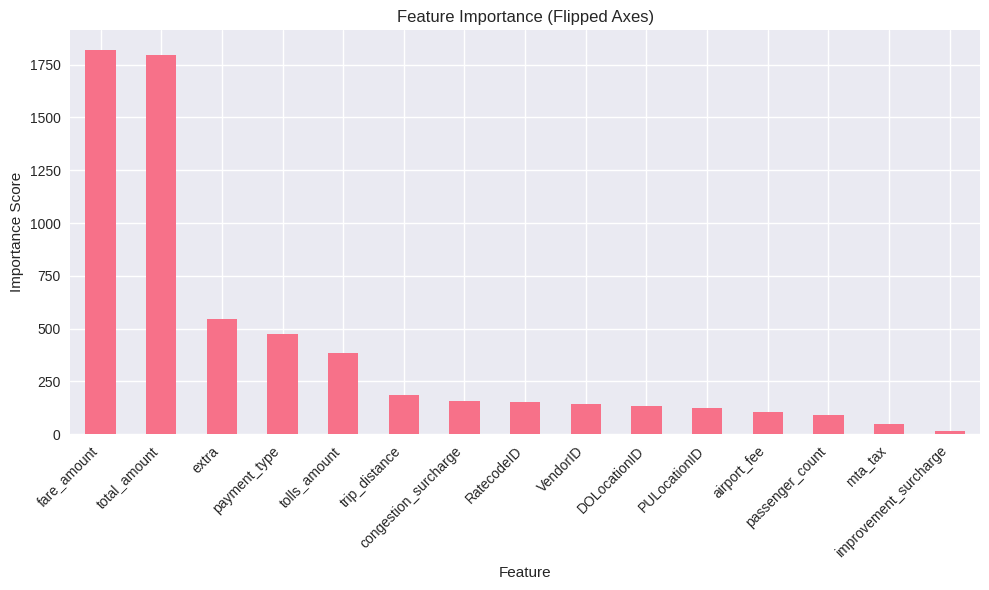

In [ ]:
booster = model.get_booster()
importance = booster.get_score(importance_type='weight')

#Convert to DataFrame
importance_df = pd.DataFrame({
    'Feature': list(importance.keys()),
    'Importance': list(importance.values())
})

#Sort by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)


ax = importance_df.head(50).plot(
    kind='bar',
    x='Feature',
    y='Importance',
    legend = False,
    figsize=(10, 6)

)
plt.title('Feature Importance (Flipped Axes)')
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Celda NUEVA - Análisis detallado de resultados
print("=== ANÁLISIS DETALLADO DE RESULTADOS ===")

# Métricas adicionales
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print(f"🔹 MSE (Error Cuadrático Medio): {mse:.4f}")
print(f"🔹 RMSE (Raíz del Error): ${rmse:.2f} por propina")
print(f"🔹 MAE (Error Absoluto): ${mae:.2f} por propina")
print(f"🔹 R² (Varianza Explicada): {r2:.4f}")

# Análisis de importancia de features
print(f"\n🔹 Feature más importante: {importance_df.iloc[0]['Feature']}")
print(f"🔹 Top 3 features: {list(importance_df['Feature'].head(3))}")

# Insight de negocio
avg_tip = data['tip_amount'].mean()
print(f"\n💡 INSIGHT: El modelo predice propinas con error de ±${rmse:.2f}")
print(f"💡 La propina promedio real es: ${avg_tip:.2f}")
print(f"💡 Esto representa un error del {(rmse/avg_tip)*100:.1f}% sobre la propina promedio")

=== ANÁLISIS DETALLADO DE RESULTADOS ===
🔹 MSE (Error Cuadrático Medio): 0.8439
🔹 RMSE (Raíz del Error): $0.92 por propina
🔹 MAE (Error Absoluto): $0.22 por propina
🔹 R² (Varianza Explicada): 0.9487

🔹 Feature más importante: fare_amount
🔹 Top 3 features: ['fare_amount', 'total_amount', 'extra']

💡 INSIGHT: El modelo predice propinas con error de ±$0.92
💡 La propina promedio real es: $3.68
💡 Esto representa un error del 25.0% sobre la propina promedio


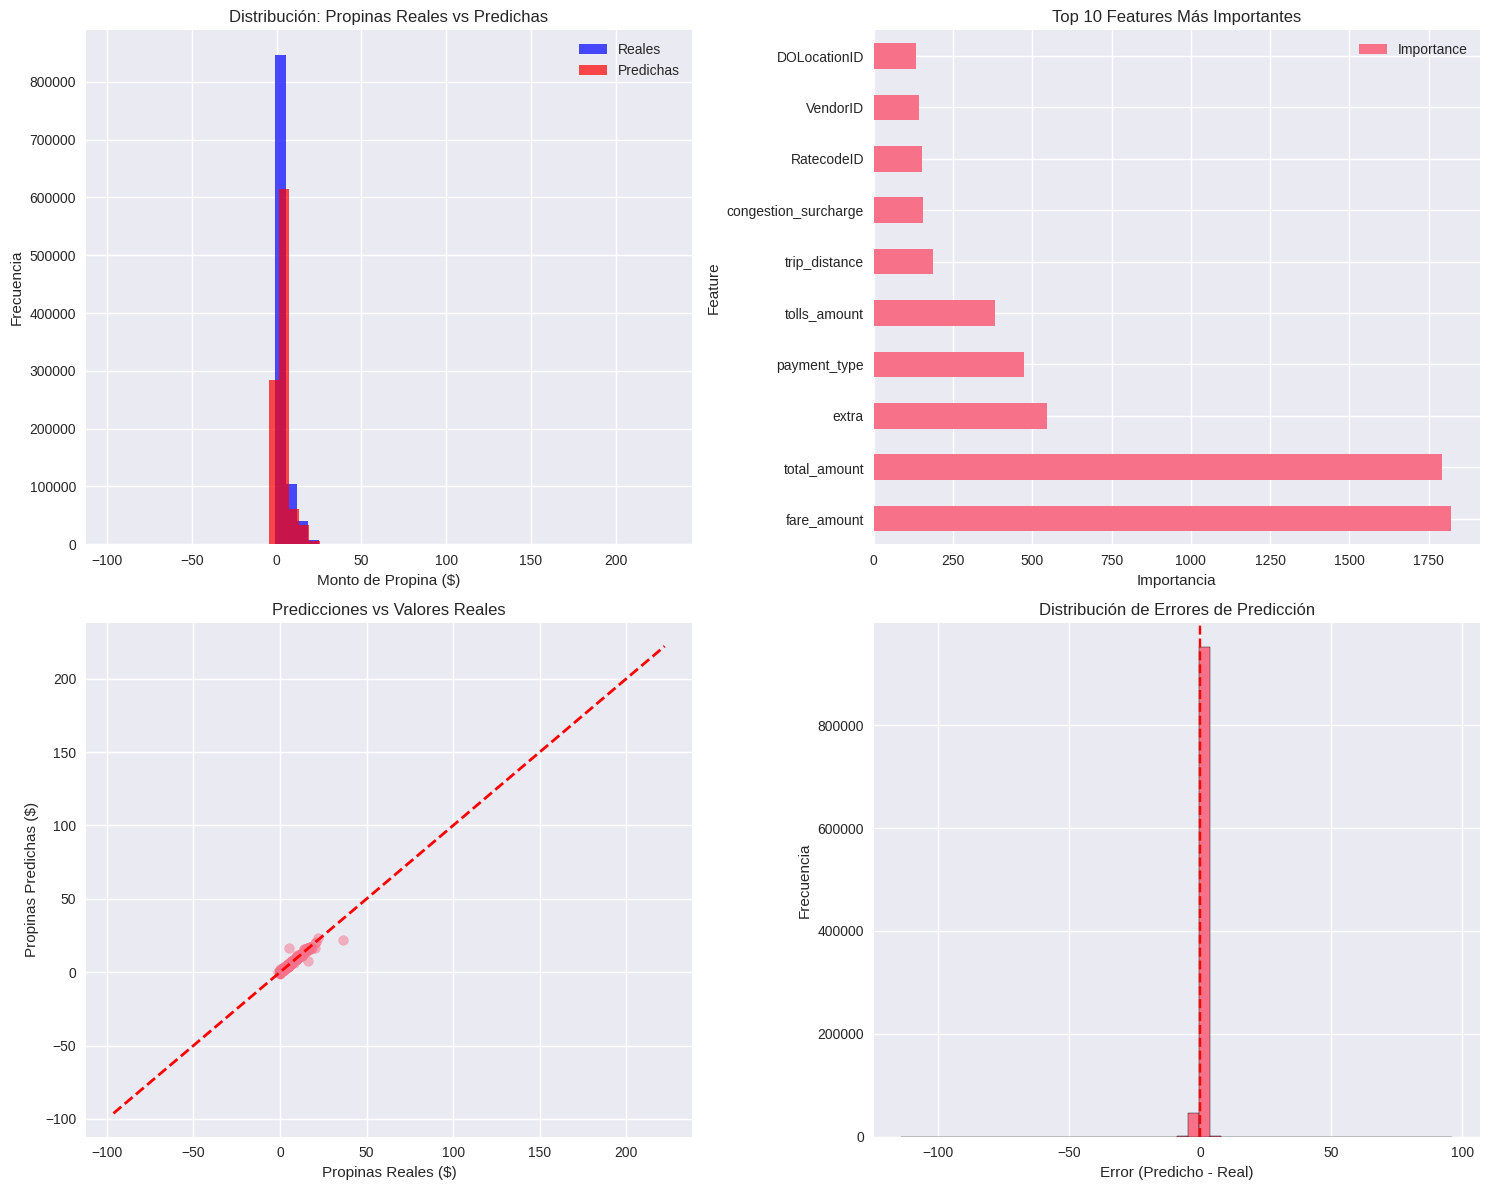

In [ ]:
# Celda NUEVA - Gráficas para portfolio
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Distribución de propinas reales vs predichas
axes[0,0].hist(y_test.values, bins=50, alpha=0.7, label='Reales', color='blue')
axes[0,0].hist(predictions, bins=50, alpha=0.7, label='Predichas', color='red')
axes[0,0].set_title('Distribución: Propinas Reales vs Predichas')
axes[0,0].set_xlabel('Monto de Propina ($)')
axes[0,0].set_ylabel('Frecuencia')
axes[0,0].legend()

# 2. Feature Importance mejorada
importance_df.head(10).plot(kind='barh', x='Feature', y='Importance', ax=axes[0,1])
axes[0,1].set_title('Top 10 Features Más Importantes')
axes[0,1].set_xlabel('Importancia')

# 3. Scatter plot predicciones vs reales (muestra reducida)
sample_idx = np.random.choice(len(y_test), 1000, replace=False)
axes[1,0].scatter(y_test.iloc[sample_idx].values, predictions[sample_idx], alpha=0.5)
axes[1,0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1,0].set_xlabel('Propinas Reales ($)')
axes[1,0].set_ylabel('Propinas Predichas ($)')
axes[1,0].set_title('Predicciones vs Valores Reales')

# 4. Errores de predicción
errors = predictions - y_test.values
axes[1,1].hist(errors, bins=50, edgecolor='black')
axes[1,1].axvline(x=0, color='red', linestyle='--')
axes[1,1].set_title('Distribución de Errores de Predicción')
axes[1,1].set_xlabel('Error (Predicho - Real)')
axes[1,1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

In [ ]:
# Celda NUEVA - Guardar para portfolio
import joblib
import json
from datetime import datetime

# Guardar modelo entrenado
joblib.dump(model, 'xgboost_nyc_taxi_tip_predictor.pkl')

# Guardar métricas
metrics = {
    'project_name': 'NYC Taxi Tip Prediction',
    'model_type': 'XGBoost Regressor',
    'dataset_size': len(data),
    'training_date': datetime.now().strftime("%Y-%m-%d"),
    'performance_metrics': {
        'mse': float(mse),
        'rmse': float(rmse),
        'mae': float(mae),
        'r2': float(r2)
    },
    'model_parameters': {
        'device': 'cuda',
        'features_used': len(x_train.columns),
        'training_samples': len(x_train),
        'test_samples': len(x_test)
    }
}

with open('model_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=4)

print("✅ Archivos guardados:")
print("   - xgboost_nyc_taxi_tip_predictor.pkl")
print("   - model_metrics.json")

✅ Archivos guardados:
   - xgboost_nyc_taxi_tip_predictor.pkl
   - model_metrics.json
